In [2]:
# We import all the needed packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error as mse
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.api import ExponentialSmoothing

In [3]:
from Forecasts import NaiveSeasonalWithDrift, TripleExponentialSmoothing, evaluate_forecast, make_rolling_splits

In [4]:
#Import the data
tsa_data = pd.read_csv("../data/tsa-throughput-data-complete.csv")

In [5]:
#We format the data lightly
tsa_data['DateTime'] = pd.to_datetime(tsa_data['DateTime']) #Changing datetime column type
#We want to ignore checkpoints, so we sum over all of the checkpoints at each airport
tsa_airport_data = tsa_data.groupby(["DateTime", "Airport Code", "Airport Name", "City", "State"], as_index=False)["Total Passenger Throughput"].sum()

We will work with data from one airport, Chicago O'Hare International Airport.
We want to test some baseline forecasts for the daily passenger throughput in this airport.
We first run a simple time-series split with training on 2022,2023 and 2024 data, and keeping 2025 data upto June 23, 2025 as holdout.

Later we will use a cross-validation time-series split for better accuracy.

Let's first see a plot of the data first.

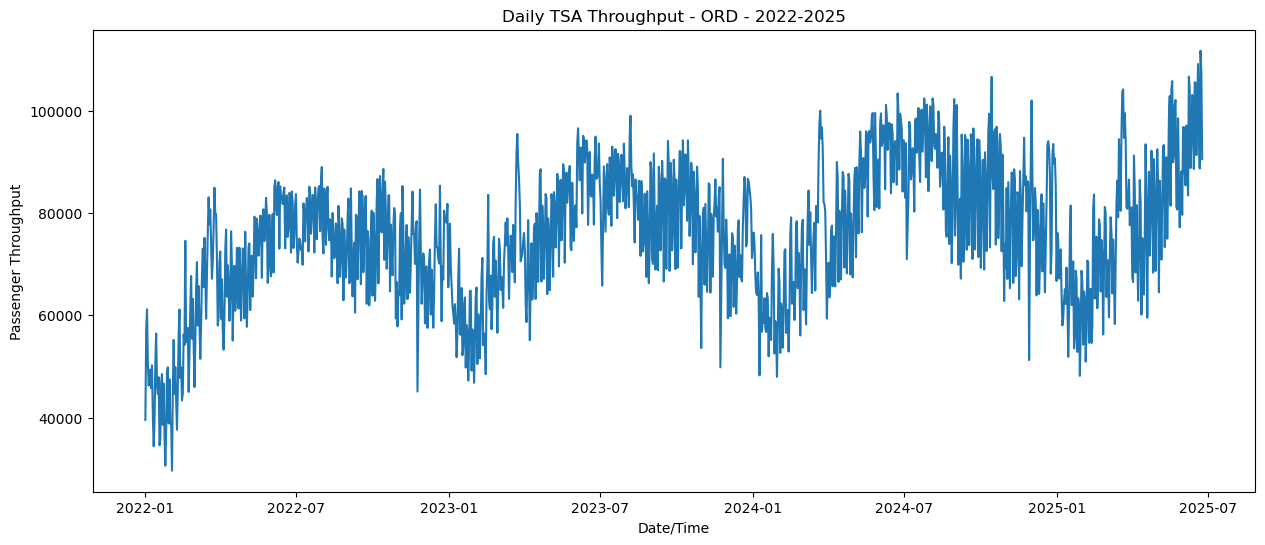

In [6]:

ord_data = tsa_airport_data[tsa_airport_data['Airport Code'] == 'ORD'] #Fixing our airport to be O'Hare
ord_data = tsa_airport_data[tsa_airport_data['Airport Code'] == 'ORD']

ord_daily = ord_data.groupby(pd.Grouper(key='DateTime', freq='D'))['Total Passenger Throughput'].sum()
ord_daily = ord_daily.reset_index()
ord_daily.columns = ['DateTime', 'Total Passenger Throughput']

ord_daily = ord_daily[ord_daily['DateTime'] <= '2025-06-24'] #We only want to use data up to June 24, 2025
plt.figure(figsize=(15, 6))
plt.plot(ord_daily['DateTime'], ord_daily['Total Passenger Throughput'])
plt.title('Daily TSA Throughput - ORD - 2022-2025')
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.show()

As we can observe there is a clear yearly seasonality to this data, and a mild positive trend as we progress from 2022 to 2025.

We see there is yearly seasonality in the data and also a slight upward trend.
We want to generate some baseline predictions. 

In [7]:
#Selecting the Training Data
ord_data_train=ord_data[ord_data['DateTime'] < '2025-01-01']
ord_daily_train=ord_data_train.groupby(pd.Grouper(key='DateTime', freq='D'))['Total Passenger Throughput'].sum()
#Selecting the Holdout Data
ord_data_ho=ord_data[(ord_data['DateTime'] > '2024-12-31') & (ord_data['DateTime'] < '2025-06-24')]
ord_daily_ho=ord_data_ho.groupby(pd.Grouper(key='DateTime', freq='D'))['Total Passenger Throughput'].sum()

print('Training Data')
print(ord_daily_train)
print("")
print('Holdout Data')
print(ord_daily_ho)


Training Data
DateTime
2022-01-01    39533
2022-01-02    57237
2022-01-03    61147
2022-01-04    50709
2022-01-05    46234
              ...  
2024-12-27    93459
2024-12-28    89595
2024-12-29    90659
2024-12-30    85391
2024-12-31    66692
Freq: D, Name: Total Passenger Throughput, Length: 1096, dtype: int64

Holdout Data
DateTime
2024-12-31     66408
2025-01-01     76087
2025-01-02     74477
2025-01-03     67184
2025-01-04     67206
               ...  
2025-06-19    109081
2025-06-20     97410
2025-06-21     88671
2025-06-22    111687
2025-06-23    107462
Freq: D, Name: Total Passenger Throughput, Length: 175, dtype: int64


We will use two baseline models - a naive seasonal forecast with drift (which was covered in the problem sessions) and triple exponential smoothing.


Time for some predictions!

In [8]:
#Calling nswd
nswd_test = NaiveSeasonalWithDrift(season_length=365)
nswd_test.fit(ord_daily_train)
nswd_forecast=nswd_test.forecast(175)
evaluate_forecast(ord_daily_ho.values, nswd_forecast,
                  model_name="Naive Seasonal With Drift | 2022-2024 Train | H1 2025 Holdout") #error evaluation
#Calling Exponential Smoothing
es=TripleExponentialSmoothing(season_length=365)
es.fit(ord_daily_train)
es_forecast = es.forecast(175)  
evaluate_forecast(ord_daily_ho.values, es_forecast,
                  model_name="Triple Exponential Smoothing | 2022-2024 Train | H1 2025 Holdout") #error evaluation



Naive Seasonal With Drift | 2022-2024 Train | H1 2025 Holdout
  MAE:  8,828
  MAPE: 11.31%
  RMSE: 10,308

Triple Exponential Smoothing | 2022-2024 Train | H1 2025 Holdout
  MAE:  6,643
  MAPE: 9.16%
  RMSE: 8,427


{'mae': np.float64(6643.233452982804),
 'mape': np.float64(9.16305178996286),
 'rmse': np.float64(8426.896862672715)}

Let's plot how the two baseline models fared with the holdout data.

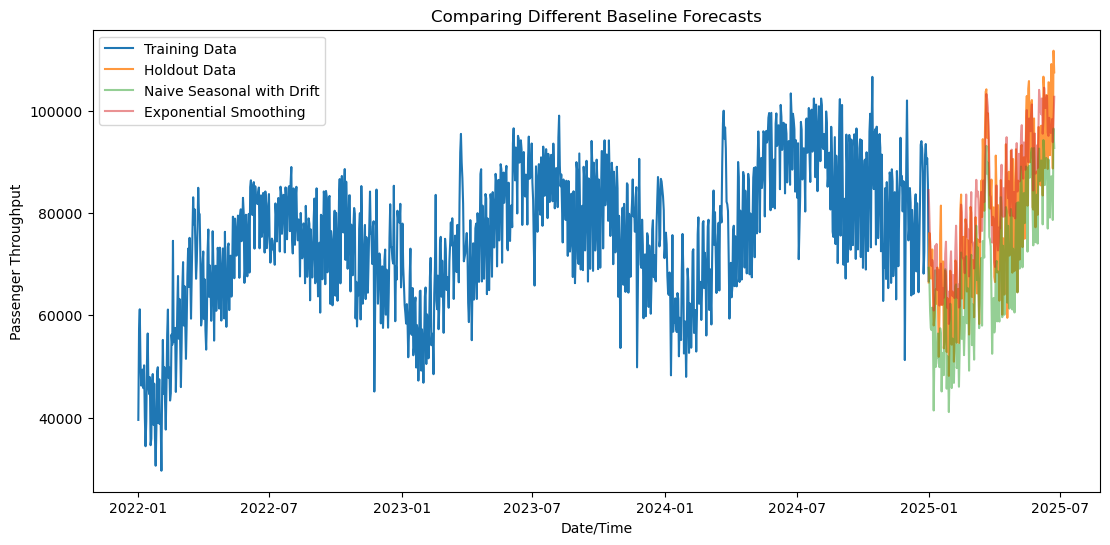

In [9]:
#Plotting the data
plt.figure(figsize=(13, 6))
plt.plot(ord_daily_train.index,ord_daily_train, label='Training Data')
plt.plot(ord_daily_ho.index,ord_daily_ho, label='Holdout Data', alpha=0.8)
plt.plot(ord_daily_ho.index,nswd_forecast, label="Naive Seasonal with Drift",alpha=0.5)
plt.plot(ord_daily_ho.index,es_forecast, label="Exponential Smoothing",alpha=0.5)
plt.title('Comparing Different Baseline Forecasts')
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.legend()
plt.show()

We can zoom into the section with just the 2024 data to better visualize how close the predictions were.

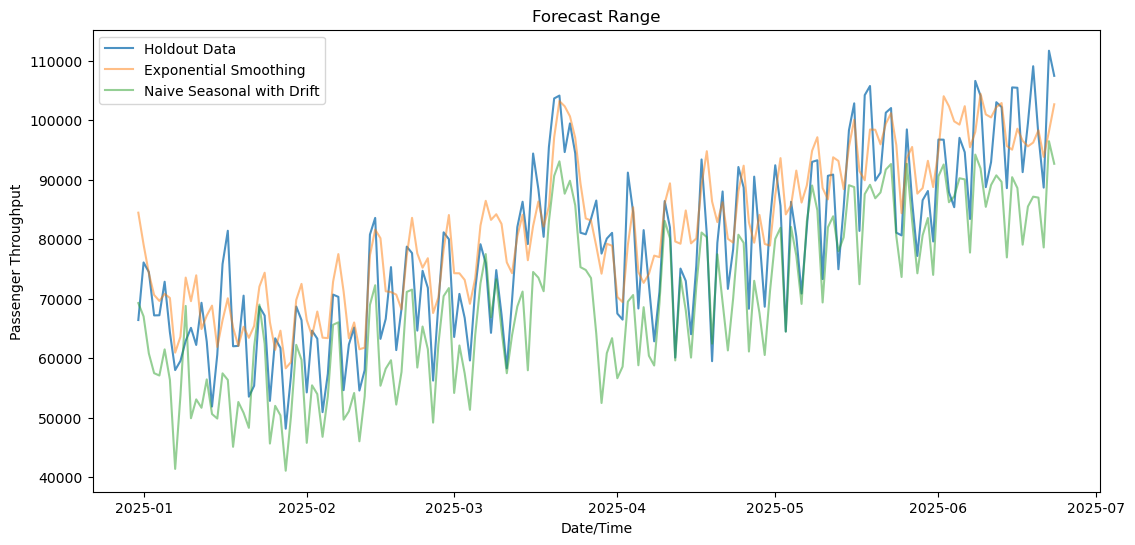

In [10]:
#Let's visualize only the holdout data and exp smoothing
plt.figure(figsize=(13, 6))
plt.plot(ord_daily_ho.index,ord_daily_ho, label='Holdout Data',alpha=0.8)
plt.plot(ord_daily_ho.index,es_forecast, label="Exponential Smoothing",alpha=0.5)
plt.plot(ord_daily_ho.index,nswd_forecast, label="Naive Seasonal with Drift",alpha=0.5)
plt.title('Forecast Range')
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.legend()
plt.show()

Let's run a cross-validated split now, with training by rolling splits. We have a baseline of 2022,2023 and an additional 90 days at each fold. The final date is June 24,2025.

In [12]:
ord_daily = ord_daily[ord_daily['DateTime'] <= '2025-06-23']
splits = make_rolling_splits(ord_daily, date_col='DateTime', n_splits=5, step_days=90)



Split 1: train → 2024-03-30 | test 2024-03-31 → 2024-06-28 (90 days)
Split 2: train → 2024-06-28 | test 2024-06-29 → 2024-09-26 (90 days)
Split 3: train → 2024-09-26 | test 2024-09-27 → 2024-12-25 (90 days)
Split 4: train → 2024-12-25 | test 2024-12-26 → 2025-03-25 (90 days)
Split 5: train → 2025-03-25 | test 2025-03-26 → 2025-06-23 (90 days)


Lets run the baseline models on these splits now.

In [13]:
#For NSWD
results = []

for i, (train_idx, test_idx) in enumerate(splits):
    train = ord_daily.iloc[train_idx]['Total Passenger Throughput']
    test  = ord_daily.iloc[test_idx]['Total Passenger Throughput']

    model = NaiveSeasonalWithDrift(season_length=365)
    model.fit(train)
    predicted = model.forecast(h=len(test))

    metrics = evaluate_forecast(test.values, predicted, model_name=f"Split {i+1}")
    metrics['split'] = i + 1
    results.append(metrics)

# Summary across all splits
results_df = pd.DataFrame(results).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_df['mape'].mean():.2f}%")
print(f"  RMSE: {results_df['rmse'].mean():,.0f}")


Split 1
  MAE:  20,708
  MAPE: 23.64%
  RMSE: 22,981

Split 2
  MAE:  9,248
  MAPE: 10.88%
  RMSE: 11,511

Split 3
  MAE:  14,555
  MAPE: 19.38%
  RMSE: 17,957

Split 4
  MAE:  16,882
  MAPE: 23.29%
  RMSE: 19,221

Split 5
  MAE:  14,919
  MAPE: 16.93%
  RMSE: 17,854

CV Average:
  MAE:  15,263
  MAPE: 18.82%
  RMSE: 17,905


In [14]:
#For Exp. smoothing
results_tes = []

for i, (train_idx, test_idx) in enumerate(splits):
    train = ord_daily.iloc[train_idx]['Total Passenger Throughput']
    test  = ord_daily.iloc[test_idx]['Total Passenger Throughput']

    model = TripleExponentialSmoothing(season_length=365)
    model.fit(train)
    predicted = model.forecast(h=len(test))

    metrics = evaluate_forecast(test.values, predicted.values, model_name=f"Split {i+1}")
    metrics['split'] = i + 1
    results_tes.append(metrics)

results_tes_df = pd.DataFrame(results_tes).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_tes_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_tes_df['mape'].mean():.2f}%")
print(f"  RMSE: {results_tes_df['rmse'].mean():,.0f}")


Split 1
  MAE:  8,680
  MAPE: 10.38%
  RMSE: 10,277

Split 2
  MAE:  9,936
  MAPE: 11.71%
  RMSE: 11,644

Split 3
  MAE:  10,626
  MAPE: 13.84%
  RMSE: 12,795

Split 4
  MAE:  8,549
  MAPE: 12.82%
  RMSE: 10,445

Split 5
  MAE:  9,529
  MAPE: 11.50%
  RMSE: 11,712

CV Average:
  MAE:  9,464
  MAPE: 12.05%
  RMSE: 11,375


Exponential smoothing does much better here. 

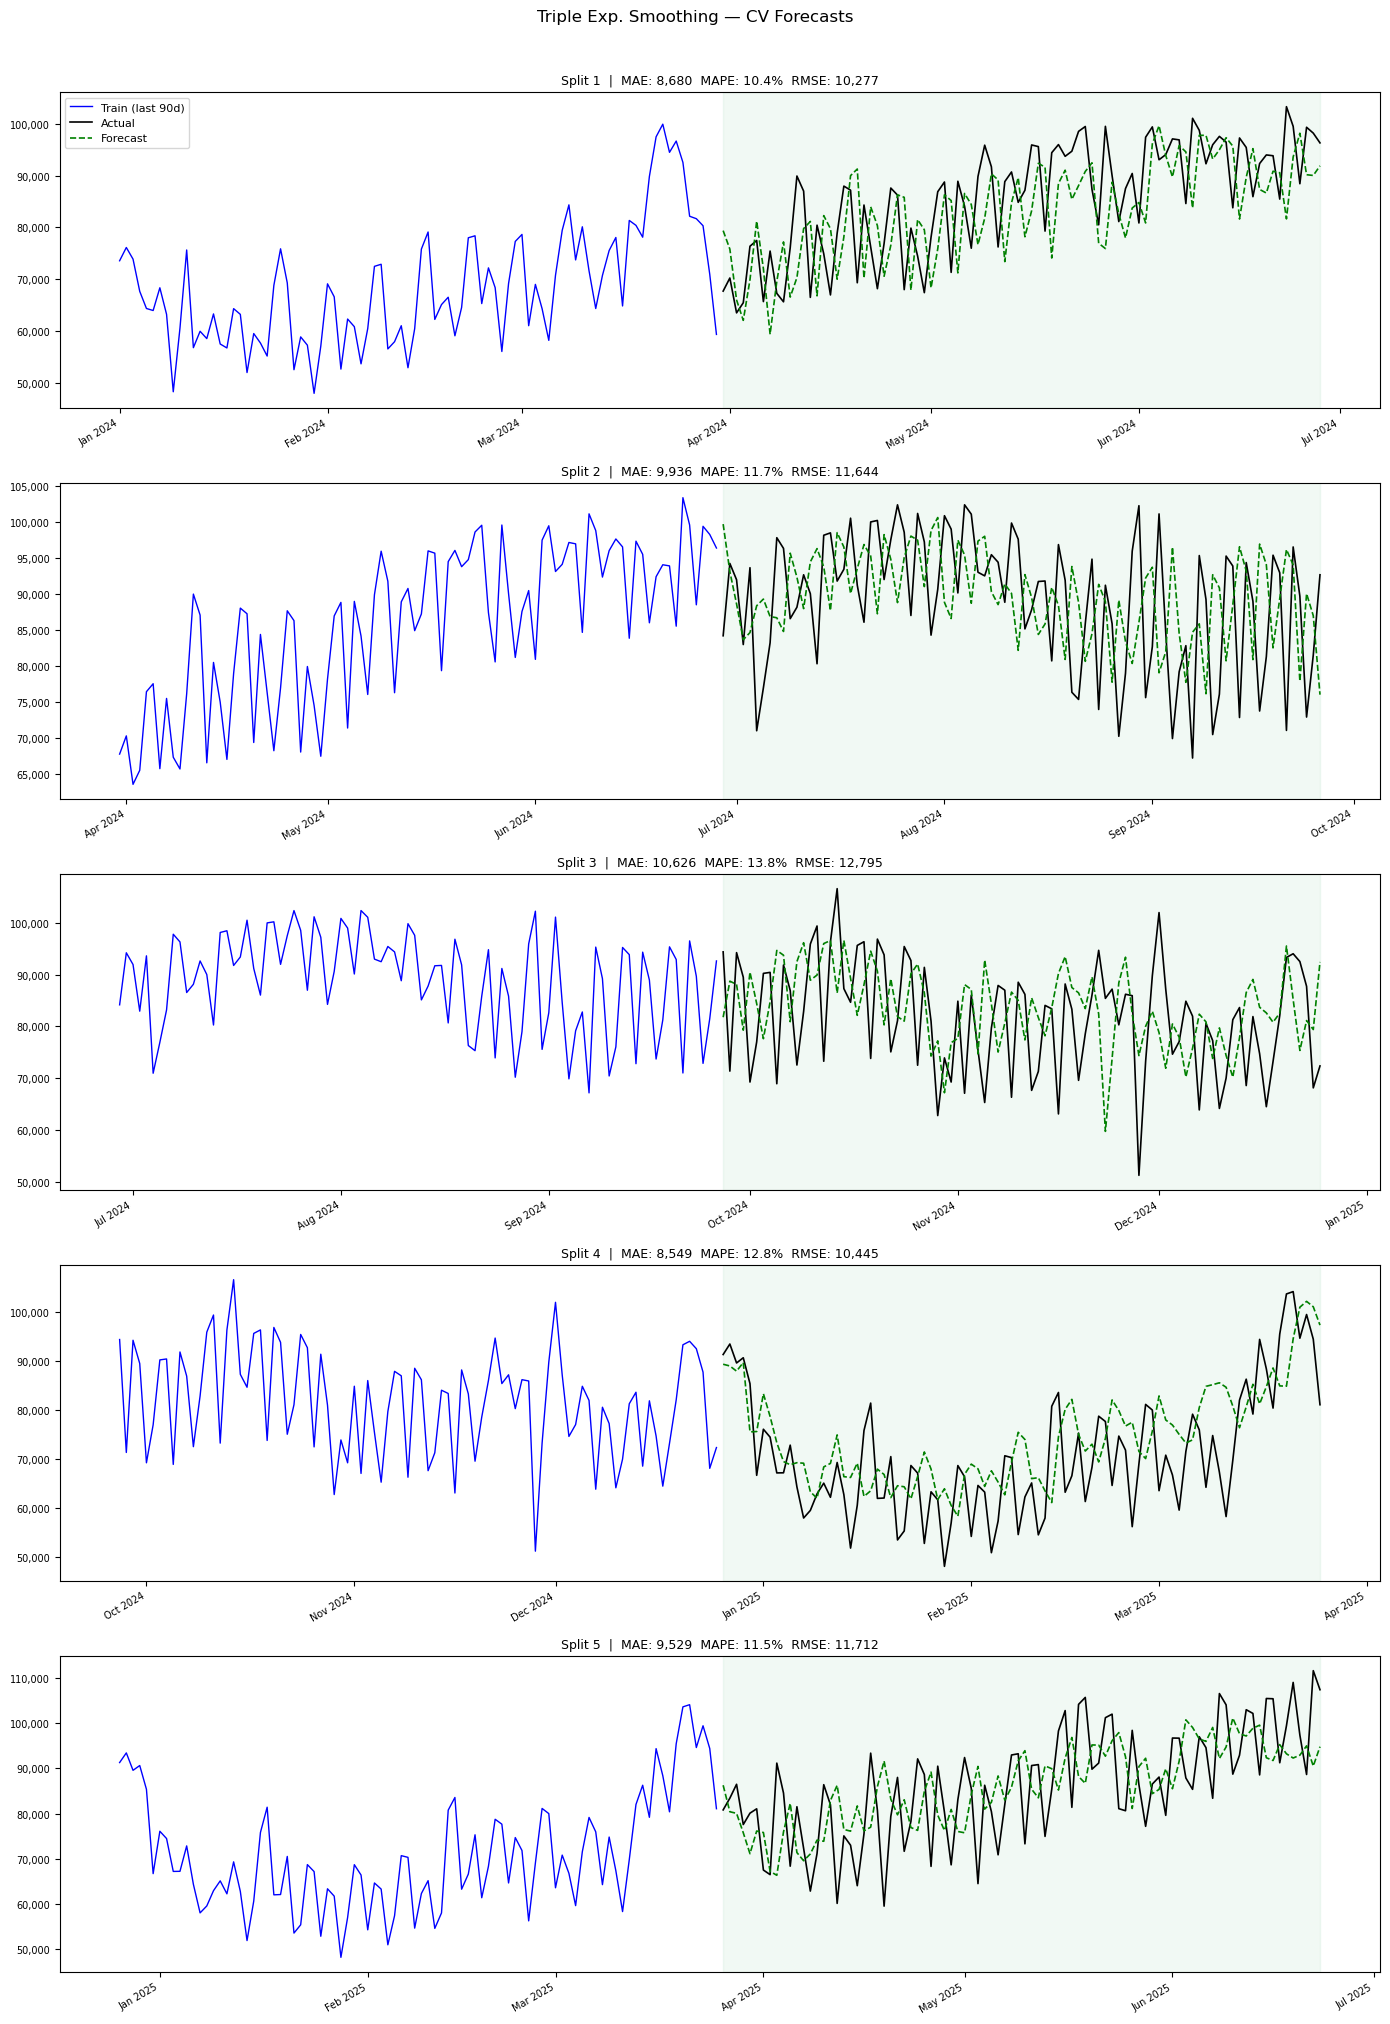

In [16]:
#Plot for Exponential Smoothing
from matplotlib import dates as mdates
fig, axes = plt.subplots(5, 1, figsize=(14, 20))
fig.suptitle('Triple Exp. Smoothing — CV Forecasts', y=1.01)

for i, (train_idx, test_idx) in enumerate(splits):
    ax = axes[i]

    train_dates = ord_daily.iloc[train_idx]['DateTime']
    test_dates  = ord_daily.iloc[test_idx]['DateTime']
    train_vals  = ord_daily.iloc[train_idx]['Total Passenger Throughput']
    test_vals   = ord_daily.iloc[test_idx]['Total Passenger Throughput']

    model = TripleExponentialSmoothing(season_length=365)
    model.fit(train_vals)
    predicted = model.forecast(h=len(test_vals)).values

    train_plot_dates = train_dates.iloc[-90:]
    train_plot_vals  = train_vals.iloc[-90:]

    ax.plot(train_plot_dates, train_plot_vals,
            color='blue', linewidth=1, label='Train (last 90d)')
    ax.plot(test_dates, test_vals,
            color='black', linewidth=1.2, label='Actual')
    ax.plot(test_dates, predicted,
            color='green', linewidth=1.2, linestyle='--', label='Forecast')

    ax.axvspan(test_dates.iloc[0], test_dates.iloc[-1], alpha=0.07, color='mediumseagreen')

    row = results_tes_df.loc[i + 1]
    ax.set_title(
        f'Split {i+1}  |  MAE: {row["mae"]:,.0f}  MAPE: {row["mape"]:.1f}%  RMSE: {row["rmse"]:,.0f}',
        fontsize=9
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.tick_params(axis='y', labelsize=7)

    if i == 0:
        ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()